In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"mokshitacv","key":"3b7f5f30e88fabe36f6f23ac5f12cfef"}'}

In [2]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d derrickmwiti/google-2019-cluster-sample

Dataset URL: https://www.kaggle.com/datasets/derrickmwiti/google-2019-cluster-sample
License(s): CC-BY-NC-SA-4.0
100% 96.7M/96.7M [00:00<00:00, 235MB/s]



In [4]:
!unzip google-2019-cluster-sample.zip

Archive:  google-2019-cluster-sample.zip
  inflating: borg_traces_data.csv    


In [5]:
import os
os.listdir()

['.config',
 'google-2019-cluster-sample.zip',
 'borg_traces_data.csv',
 'sample_data']

In [6]:
import pandas as pd
df = pd.read_csv("borg_traces_data.csv")
df.head()

,Unnamed: 0,time,instance_events_type,collection_id,scheduling_class,collection_type,priority,alloc_collection_id,instance_index,machine_id,...,assigned_memory,page_cache_memory,cycles_per_instruction,memory_accesses_per_instruction,sample_rate,cpu_usage_distribution,tail_cpu_usage_distribution,cluster,event,failed
0,0,0,2,94591244395,3,1,200,0,144,168846390496,...,0.014435,0.000415,NaN,NaN,1.0,[0.00314331 0.00381088 0.00401306 0.00415039 0...,[0.00535583 0.00541687 0.00548553 0.00554657 0...,7,FAIL,1
1,1,2517305308183,2,260697606809,2,0,360,221495397286,335,85515092,...,0.000000,0.000000,NaN,NaN,1.0,[1.23977661e-05 1.23977661e-05 1.23977661e-05 ...,[1.23977661e-05 1.23977661e-05 1.23977661e-05 ...,7,FAIL,1
2,2,195684022913,6,276227177776,2,0,103,0,376,169321752432,...,0.010422,0.000235,0.939919,0.001318,1.0,[0.01344299 0.01809692 0.0201416 0.02246094 0...,[0.02902222 0.02929688 0.0295105 0.0296936 0...,7,SCHEDULE,0
3,3,0,2,10507389885,3,0,200,0,1977,178294817221,...,0.041626,0.000225,1.359102,0.007643,1.0,[0.03704834 0.04125977 0.04290771 0.04425049 0...,[0.05535889 0.05584717 0.05633545 0.05718994 0...,8,FAIL,1
4,4,1810627494172,3,25911621841,2,0,0,0,3907,231364893292,...,0.000272,0.000010,NaN,NaN,1.0,[0. 0. 0. 0. 0...,[0.00041485 0.00041485 0.00041485 0.00041485 0...,2,FINISH,0


In [7]:
df_clean = df.copy()

In [8]:
print(type(df_clean))

<class 'pandas.core.frame.DataFrame'>


In [9]:
print(df_clean.columns)

Index(['Unnamed: 0', 'time', 'instance_events_type', 'collection_id',
       'scheduling_class', 'collection_type', 'priority',
       'alloc_collection_id', 'instance_index', 'machine_id',
       'resource_request', 'constraint', 'collections_events_type', 'user',
       'collection_name', 'collection_logical_name',
       'start_after_collection_ids', 'vertical_scaling', 'scheduler',
       'start_time', 'end_time', 'average_usage', 'maximum_usage',
       'random_sample_usage', 'assigned_memory', 'page_cache_memory',
       'cycles_per_instruction', 'memory_accesses_per_instruction',
       'sample_rate', 'cpu_usage_distribution', 'tail_cpu_usage_distribution',
       'cluster', 'event', 'failed'],
      dtype='object')


In [10]:
import numpy as np
import ast  # ast.literal_eval converts string to Python list safely

# Function to convert string to list
def str_to_array(s):
    try:
        return np.array(ast.literal_eval(s.replace(' ', ',')))  # replace spaces with commas
    except:
        return np.array([0.0])  # if something fails, return zero array

# Apply conversion
df_clean['cpu_array'] = df_clean['cpu_usage_distribution'].apply(str_to_array)
df_clean['tail_cpu_array'] = df_clean['tail_cpu_usage_distribution'].apply(str_to_array)

In [11]:
import numpy as np
import ast

def safe_str_to_array(s):
    try:
        # Convert string to list
        arr = np.array(ast.literal_eval(s.replace(' ', ',')))
        if arr.size == 0:  # empty array
            return np.array([0.0])
        else:
            return arr
    except:
        return np.array([0.0])  # fallback if parsing fails

# Apply conversion
df_clean['cpu_array'] = df_clean['cpu_usage_distribution'].apply(safe_str_to_array)
df_clean['tail_cpu_array'] = df_clean['tail_cpu_usage_distribution'].apply(safe_str_to_array)

In [12]:
# Safe functions to handle empty arrays
def safe_mean(arr):
    return np.mean(arr) if arr.size > 0 else 0.0

def safe_max(arr):
    return np.max(arr) if arr.size > 0 else 0.0

def safe_std(arr):
    return np.std(arr) if arr.size > 0 else 0.0

# CPU usage
df_clean['cpu_mean'] = df_clean['cpu_array'].apply(safe_mean)
df_clean['cpu_max'] = df_clean['cpu_array'].apply(safe_max)
df_clean['cpu_std'] = df_clean['cpu_array'].apply(safe_std)

# Tail CPU usage
df_clean['tail_cpu_mean'] = df_clean['tail_cpu_array'].apply(safe_mean)
df_clean['tail_cpu_max'] = df_clean['tail_cpu_array'].apply(safe_max)
df_clean['tail_cpu_std'] = df_clean['tail_cpu_array'].apply(safe_std)

In [13]:
df_clean = df_clean.drop(
    ['cpu_usage_distribution', 'tail_cpu_usage_distribution',
     'cpu_array', 'tail_cpu_array'],
    axis=1,
    errors='ignore'  # <- this prevents KeyError
)

In [14]:
print(df_clean.columns)

Index(['Unnamed: 0', 'time', 'instance_events_type', 'collection_id',
       'scheduling_class', 'collection_type', 'priority',
       'alloc_collection_id', 'instance_index', 'machine_id',
       'resource_request', 'constraint', 'collections_events_type', 'user',
       'collection_name', 'collection_logical_name',
       'start_after_collection_ids', 'vertical_scaling', 'scheduler',
       'start_time', 'end_time', 'average_usage', 'maximum_usage',
       'random_sample_usage', 'assigned_memory', 'page_cache_memory',
       'cycles_per_instruction', 'memory_accesses_per_instruction',
       'sample_rate', 'cluster', 'event', 'failed', 'cpu_mean', 'cpu_max',
       'cpu_std', 'tail_cpu_mean', 'tail_cpu_max', 'tail_cpu_std'],
      dtype='object')


In [15]:
features = [
    'assigned_memory', 'page_cache_memory',
    'cycles_per_instruction', 'memory_accesses_per_instruction',

    'cpu_mean', 'cpu_max', 'cpu_std',
    'tail_cpu_mean', 'tail_cpu_max', 'tail_cpu_std',

    'average_usage_cpus', 'average_usage_memory',
    'maximum_usage_cpus', 'maximum_usage_memory',
    'random_sample_usage_cpus', 'random_sample_usage_memory'
]

In [16]:
import ast

def extract_cpus(s):
    try:
        d = ast.literal_eval(s)
        return float(d.get('cpus', 0.0))
    except:
        return 0.0

def extract_memory(s):
    try:
        d = ast.literal_eval(s)
        val = d.get('memory', 0.0)
        if val is None:
            return 0.0
        return float(val)
    except:
        return 0.0

for col in ['average_usage', 'maximum_usage', 'random_sample_usage']:
    df_clean[f'{col}_cpus'] = df_clean[col].apply(extract_cpus)
    df_clean[f'{col}_memory'] = df_clean[col].apply(extract_memory)

In [17]:
df_clean = df_clean.drop([
    'average_usage',
    'maximum_usage',
    'random_sample_usage'
], axis=1)

In [18]:
import numpy as np

X = df_clean.select_dtypes(include=[np.number]).drop(['failed'], axis=1)

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [20]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

iso_forest.fit(X_scaled)

IsolationForest(contamination=0.05, random_state=42)

In [21]:
df_clean['anomaly_score'] = iso_forest.decision_function(X_scaled)

# Convert to intensity
df_clean['anomaly_intensity'] = -df_clean['anomaly_score']

# Normalize
df_clean['anomaly_intensity'] = (
    (df_clean['anomaly_intensity'] - df_clean['anomaly_intensity'].min()) /
    (df_clean['anomaly_intensity'].max() - df_clean['anomaly_intensity'].min())
)

In [22]:
df_clean['resource_stress'] = (
    df_clean['cpu_mean'] +
    df_clean['average_usage_cpus'] +
    df_clean['average_usage_memory']
)

df_clean['resource_stress'] = (
    (df_clean['resource_stress'] - df_clean['resource_stress'].min()) /
    (df_clean['resource_stress'].max() - df_clean['resource_stress'].min())
)

In [23]:
df_clean['priority_factor'] = df_clean['priority'] / df_clean['priority'].max()

In [24]:
df_clean['risk_score'] = (
    0.5 * df_clean['anomaly_intensity'] +
    0.3 * df_clean['resource_stress'] +
    0.2 * df_clean['priority_factor']
)

In [25]:
df_clean = df_clean.sort_values('time')

df_clean['anomaly_trend'] = (
    df_clean['anomaly_intensity']
    .rolling(window=5, min_periods=1)
    .mean()
)

In [26]:
df_clean['cpu_spike'] = (
    df_clean['maximum_usage_cpus'] - df_clean['average_usage_cpus']
)

df_clean['cpu_spike'] = (
    (df_clean['cpu_spike'] - df_clean['cpu_spike'].min()) /
    (df_clean['cpu_spike'].max() - df_clean['cpu_spike'].min())
)

In [27]:
df_clean['final_score'] = (
    0.5 * df_clean['risk_score'] +
    0.2 * df_clean['anomaly_intensity'] +
    0.2 * df_clean['anomaly_trend'] +
    0.1 * df_clean['cpu_spike']
)

In [28]:
low_threshold = df_clean['final_score'].quantile(0.60)
high_threshold = df_clean['final_score'].quantile(0.95)

In [29]:
def classify_risk(score):
    if score > high_threshold:
        return "HIGH"
    elif score > low_threshold:
        return "MEDIUM"
    else:
        return "LOW"


def decide_action(row):
    risk = classify_risk(row['final_score'])

    if risk == "HIGH":
        return "AUTO_HEAL"
    elif risk == "MEDIUM":
        return "ALERT"
    else:
        return "IGNORE"

df_clean['action'] = df_clean.apply(decide_action, axis=1)

In [30]:
def execute_action(action):

    if action == "AUTO_HEAL":
        return "Restart VM"

    elif action == "ALERT":
        return "Send Alert"

    else:
        return "Continue Monitoring"

df_clean["system_action"] = (
    df_clean["action"]
    .apply(execute_action)
)

In [31]:
print(df_clean[
    ["action", "system_action"]
].head(10))

           action        system_action
316185     IGNORE  Continue Monitoring
185095     IGNORE  Continue Monitoring
185094  AUTO_HEAL           Restart VM
210186      ALERT           Send Alert
210181      ALERT           Send Alert
210176     IGNORE  Continue Monitoring
185088     IGNORE  Continue Monitoring
316227      ALERT           Send Alert
251965      ALERT           Send Alert
251964     IGNORE  Continue Monitoring


In [32]:
print(df_clean["system_action"].value_counts())

system_action
Continue Monitoring    243536
Send Alert             142063
Restart VM              20295
Name: count, dtype: int64


In [33]:
import pandas as pd

result = pd.crosstab(df_clean['action'], df_clean['failed'])
print(result)

failed          0      1
action                  
ALERT      111699  30364
AUTO_HEAL   15673   4622
IGNORE     185844  57692


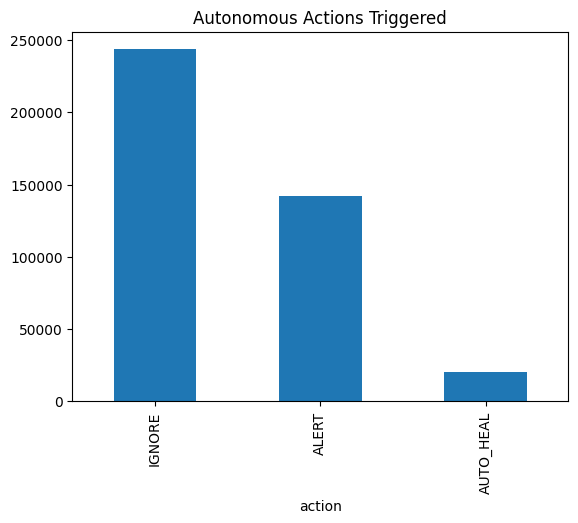

In [35]:
import matplotlib.pyplot as plt

df_clean['action'].value_counts().plot(kind='bar')

plt.title("Autonomous Actions Triggered")
plt.show()

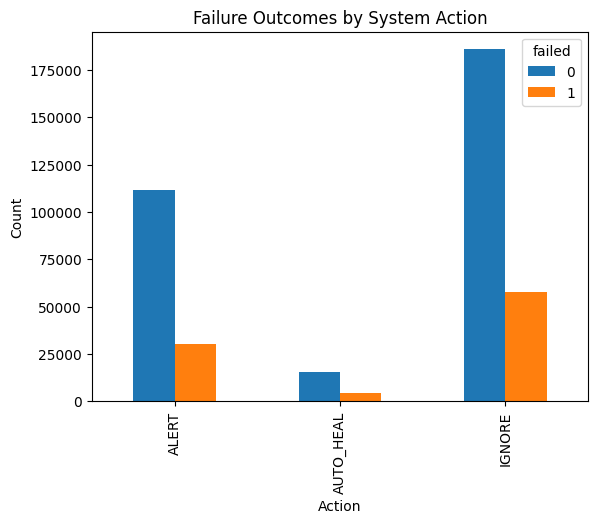

In [37]:
import matplotlib.pyplot as plt

result.plot(kind='bar')

plt.title("Failure Outcomes by System Action")
plt.xlabel("Action")
plt.ylabel("Count")

plt.show()

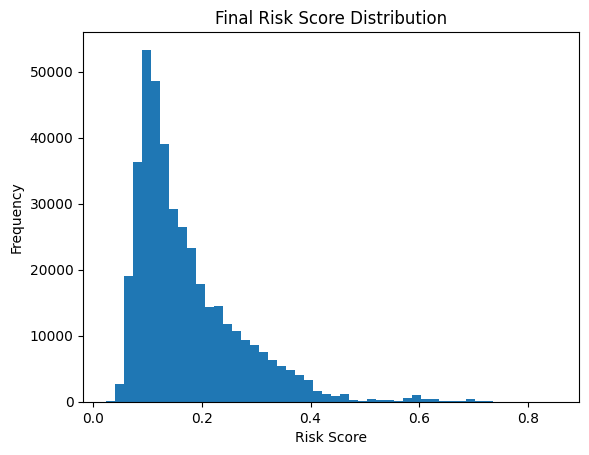

In [38]:
plt.hist(df_clean['final_score'], bins=50)

plt.title("Final Risk Score Distribution")
plt.xlabel("Risk Score")
plt.ylabel("Frequency")

plt.show()